# Эксперимент 34: Multicategory voice disorders from mel

**Статья:** Deep-Learning Classification of Multicategory Voice Disorders from Multi-Vowel Mel Spectrograms (Классификация множественных категорий голосовых нарушений из multi-vowel mel-спектрограмм с помощью глубокого обучения) 2024

**Ссылка:** [https://journals.sagepub.com/doi/10.1177/01455613261428272](https://journals.sagepub.com/doi/10.1177/01455613261428272)

**Краткое описание модели:** Mel-спектрограммы -> 2D CNN (multi-vowel inspired DL pipeline, адаптирован к бинарной метке).

**Содержание статьи:** Статья демонстрирует, что mel-представления в сочетании с DL хорошо работают для детекции голосовых нарушений и могут масштабироваться на более сложные классы. Также отмечается важность генерализации между корпусами. Эксперимент переносит архитектурный подход на вашу задачу good/bad.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Загрузка данных и извлечение признаков

In [ ]:
FEATURE_FN = lambda p: data_utils.extract_mel_spectrogram(p, n_mels=config.N_MELS, max_frames=320)
MODEL_KWARGS = {'n_mels': config.N_MELS}

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

N_FRAMES = 320

def load_feature(path):
    feat = FEATURE_FN(path)
    return feat[np.newaxis, ...]

print("Извлечение признаков (train)...")
X_train = np.stack(Parallel(n_jobs=-1)(delayed(load_feature)(p) for p in paths_train))
print("Val...")
X_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_feature)(p) for p in paths_val))
print("Test...")
X_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_feature)(p) for p in paths_test))
print("Feature tensor:", X_train.shape)

x_mean = X_train.mean(axis=(0,2,3), keepdims=True)
x_std = X_train.std(axis=(0,2,3), keepdims=True)
x_std = np.where(x_std < 1e-6, 1.0, x_std)
X_train = (X_train - x_mean) / x_std
X_val   = (X_val - x_mean) / x_std
X_test  = (X_test - x_mean) / x_std


Train: 1942, Val: 417, Test: 417
Извлечение признаков (train)...
Val...
Test...
Feature tensor: (1942, 1, 80, 320)


## 2. Обучение, валидация и тест

Device: cuda
Параметров: 440018
Epoch 1/50 train_loss=1.7031 val_f1_macro=0.5382
Epoch 2/50 train_loss=1.3863 val_f1_macro=0.5528
Epoch 3/50 train_loss=1.2420 val_f1_macro=0.6232
Epoch 4/50 train_loss=1.1622 val_f1_macro=0.6493
Epoch 5/50 train_loss=1.1650 val_f1_macro=0.5336
Epoch 6/50 train_loss=1.1715 val_f1_macro=0.5751
Epoch 7/50 train_loss=1.3872 val_f1_macro=0.5656
Epoch 8/50 train_loss=1.1161 val_f1_macro=0.6207
Epoch 9/50 train_loss=1.2606 val_f1_macro=0.6498
Epoch 10/50 train_loss=0.9795 val_f1_macro=0.6292
Epoch 11/50 train_loss=0.9710 val_f1_macro=0.5777
Epoch 12/50 train_loss=0.9458 val_f1_macro=0.6554
Epoch 13/50 train_loss=0.8702 val_f1_macro=0.6931
Epoch 14/50 train_loss=0.8128 val_f1_macro=0.5334
Epoch 15/50 train_loss=0.7385 val_f1_macro=0.6495
Epoch 16/50 train_loss=0.6786 val_f1_macro=0.6596
Epoch 17/50 train_loss=0.7607 val_f1_macro=0.7081
Epoch 18/50 train_loss=0.6037 val_f1_macro=0.6500
Epoch 19/50 train_loss=0.5317 val_f1_macro=0.6145
Epoch 20/50 train_loss=0.49

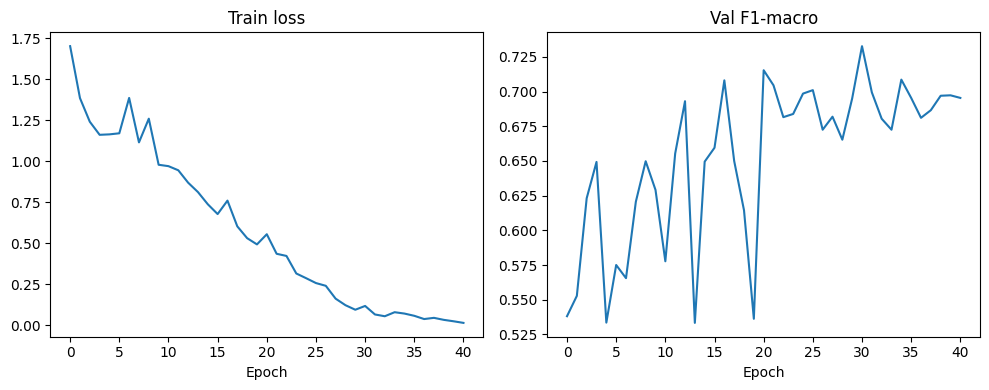

              precision    recall  f1-score   support

        good       0.80      0.87      0.83       282
         bad       0.67      0.56      0.61       135

    accuracy                           0.77       417
   macro avg       0.74      0.71      0.72       417
weighted avg       0.76      0.77      0.76       417



,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.767386,0.72102,0.607287,0.778487,0.669643,0.555556


Результат сохранён в result.csv текущего эксперимента


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(letters_train).float(), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(torch.from_numpy(X_val).float(),   torch.from_numpy(letters_val).float(),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test).float(),  torch.from_numpy(letters_test).float(),  torch.from_numpy(y_test).long())

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model = get_model(num_classes=2, n_letters=n_letters, n_frames=N_FRAMES, **MODEL_KWARGS).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("Параметров:", n_params)

weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = train_utils.get_lr_scheduler(optimizer, patience=config.LR_SCHEDULER_PATIENCE, factor=config.LR_SCHEDULER_FACTOR)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

train_losses, val_f1s = [], []
N_EPOCHS = 50

def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            logits = model(x, letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        losses.append(loss.item())
    train_losses.append(float(np.mean(losses)))

    vp, vt = eval_loader(val_loader)
    vf1 = f1_score(vt, vp, average="macro")
    val_f1s.append(vf1)
    if vf1 > best_f1:
        best_f1 = vf1
        train_utils.save_best_checkpoint(model, best_ckpt)
    scheduler.step(vf1)
    print(f"Epoch {epoch+1}/{N_EPOCHS} train_loss={train_losses[-1]:.4f} val_f1_macro={vf1:.4f}")
    if early_stopping.step(vf1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0
train_utils.load_best_checkpoint(model, best_ckpt, device)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Train loss"); plt.xlabel("Epoch")
plt.subplot(1,2,2); plt.plot(val_f1s); plt.title("Val F1-macro"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

model.eval()
all_logits = []
with torch.no_grad():
    for x, letters, _ in test_loader:
        x, letters = x.to(device), letters.to(device)
        all_logits.append(model(x, letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
display(metrics_table)
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_34_multivowel_voice_disorders",
    experiment_name="Multicategory voice disorders from mel",
    model="MelCNN2d",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="mel 2D CNN proxy",
    num_params=n_params,
    train_time_sec=train_time_sec,
)